In [ ]:
#Task 2
# Clustering and data visualization 
#Which genetic perturbations show similar effects, if any? Which clustering method(s) best 
#capture(s) the underlying biology? 
#Apply different clustering methods to the data, visualize and compare the results. Students 
#working alone only need to use data from the co-culture condition. Interpret the results 
#biologically. Do the clusters correspond to what you would expect based on the findings 
#described in the paper, e.g., the pathways that are discussed? 

In [ ]:
# Workflow
#Load the data without hvg and processed qc and separate into 3 conditions

In [22]:
# import packages
import scanpy as sc
import numpy as np
import pandas as pd

In [23]:
# Load the qc data
adata = sc.read_h5ad("../data/frangieh/adata_qc_done")

In [24]:
# Look at cell counts before separating the data perturbation_2
adata.obs["perturbation_2"].value_counts()


perturbation_2
IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64

In [25]:
#Separation into three datasets
adata_control = adata[adata.obs["perturbation_2"] == "Control"].copy()

adata_ifng = adata[adata.obs["perturbation_2"] == "IFNγ"].copy()

adata_coculture = adata[adata.obs["perturbation_2"] == "Co-culture"].copy()

In [26]:
# Normalize the dataset adata_control 
sc.pp.normalize_total(adata_control, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_control)

In [27]:
# Normalize the dataset adata_ifng 
sc.pp.normalize_total(adata_ifng, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_ifng)

In [28]:
# Normalize the dataset adata_coculture
sc.pp.normalize_total(adata_coculture, target_sum = 1e4)
sc.pp.log1p(adata_coculture)

In [29]:
print("Control:", adata_control)
print("IFNγ:", adata_ifng)
print("Co-culture:", adata_coculture)

Control: AnnData object with n_obs × n_vars = 49895 × 23711
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_t

In [30]:
#HVG selection
sc.pp.highly_variable_genes(adata_control, n_top_genes=5000)
sc.pp.highly_variable_genes(adata_ifng, n_top_genes=5000)
sc.pp.highly_variable_genes(adata_coculture, n_top_genes=5000)

In [32]:
# Save HVG-filtered datasets
adata_control_hvg = adata_control[:, adata_control.var["highly_variable"]].copy()
adata_ifng_hvg = adata_ifng[:, adata_ifng.var["highly_variable"]].copy()
adata_coculture_hvg = adata_coculture[:, adata_coculture.var["highly_variable"]].copy()

print(adata_control_hvg.shape)
print(adata_ifng_hvg.shape)
print(adata_coculture_hvg.shape)

(49895, 5000)
(74186, 5000)
(67093, 5000)


In [ ]:
# Data integration via harmony??

In [33]:
# Calculate perturbation profile log 2 fold change for avarage gene expression 
import pandas as pd
import numpy as np
from scipy.sparse import issparse

def calculate_perturbation_profiles(adata_subset, pert_col):
    """
    Calculates mean gene expression profile for each perturbation.
    Rows = perturbations
    Columns = genes
    Values = mean expression
    """

    X = adata_subset.X

    if issparse(X):
        X = X.toarray()

    expr_df = pd.DataFrame(
        X,
        index=adata_subset.obs[pert_col].values,
        columns=adata_subset.var_names
    )

    perturbation_profiles = expr_df.groupby(expr_df.index).mean()

    return perturbation_profiles

In [37]:
pert_col = "perturbation" 

profiles_control = calculate_perturbation_profiles(adata_control_hvg, pert_col)
profiles_ifng = calculate_perturbation_profiles(adata_ifng_hvg, pert_col)
profiles_coculture = calculate_perturbation_profiles(adata_coculture_hvg, pert_col)


/tmp/ipykernel_1440/2066979090.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perturbation_profiles = expr_df.groupby(expr_df.index).mean()


In [36]:
adata_control_hvg.obs.columns
adata_ifng_hvg.obs.columns
adata_coculture_hvg.obs.columns

Index(['library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA',
       'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer',
       'disease', 'perturbation_type', 'celltype', 'organism',
       'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito',
       'percent_ribo', 'n_genes', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts',
       'doublet_scores', 'predicted_doublets', 'doublet_info'],
      dtype='object')

In [38]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

control_scaled = scaler.fit_transform(profiles_control)
ifng_scaled = scaler.fit_transform(profiles_ifng)
coculture_scaled = scaler.fit_transform(profiles_coculture)

In [42]:
#Compute PCA
from sklearn.decomposition import PCA
# Compute 50 principal components
pca = PCA(n_components=50, random_state=42)
control_pca = pca.fit_transform(control_scaled)
ifng_pca = pca.fit_transform(ifng_scaled)
coculture_pca = pca.fit_transform(coculture_scaled)
print(control_pca.shape)
print(ifng_pca.shape)
print(coculture_pca.shape)

(249, 50)
(249, 50)
(249, 50)


In [ ]:
#K means clustering
# Control dateset 

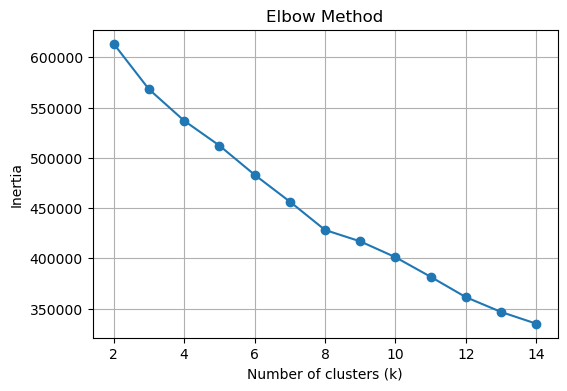

In [48]:
#Elbow method 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = control_pca

k_clusters = range(2, 15)
inertia = []

for k in k_clusters:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_clusters, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

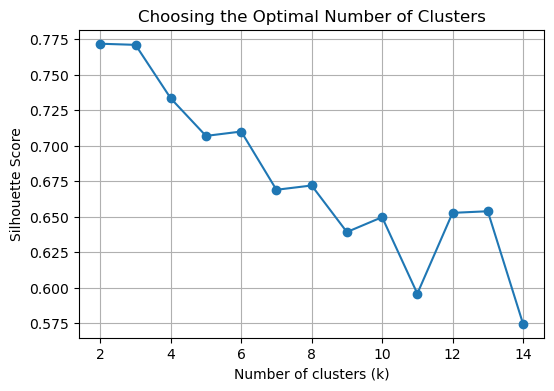

Best k according to silhouette score: 2


In [49]:
#Silhouette method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 15)
scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(control_pca)
    score = silhouette_score(control_pca, labels)
    scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Choosing the Optimal Number of Clusters")
plt.grid(True)
plt.show()
best_k = k_values[scores.index(max(scores))]
print(f"Best k according to silhouette score: {best_k}")

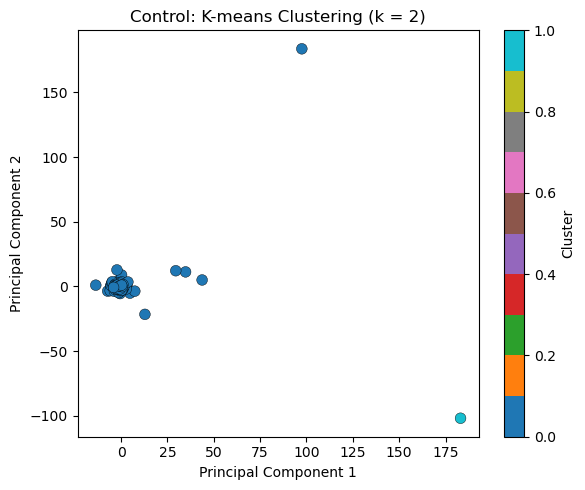

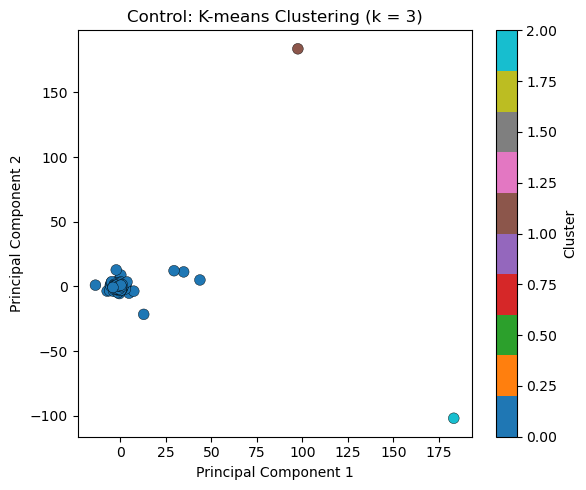

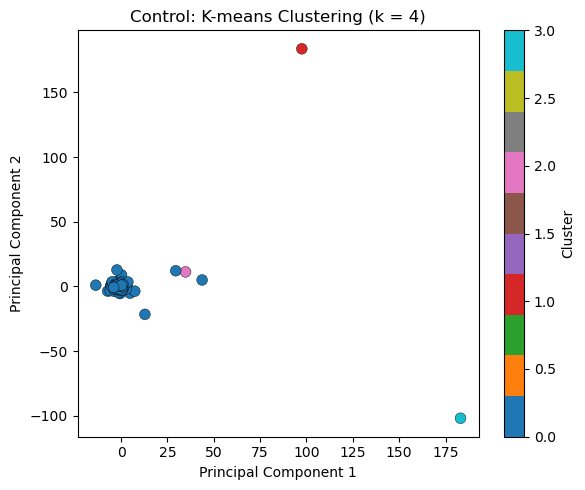

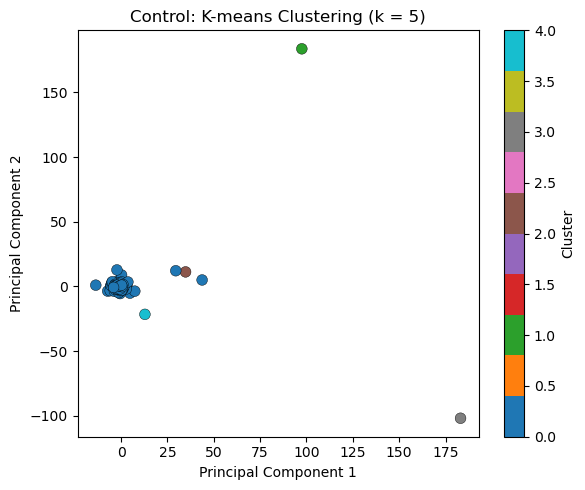

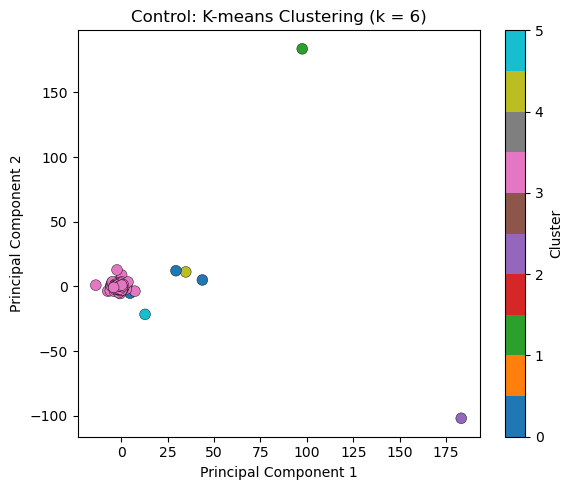

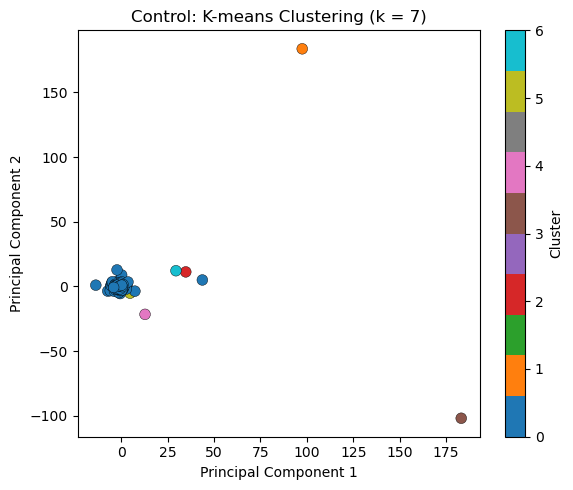

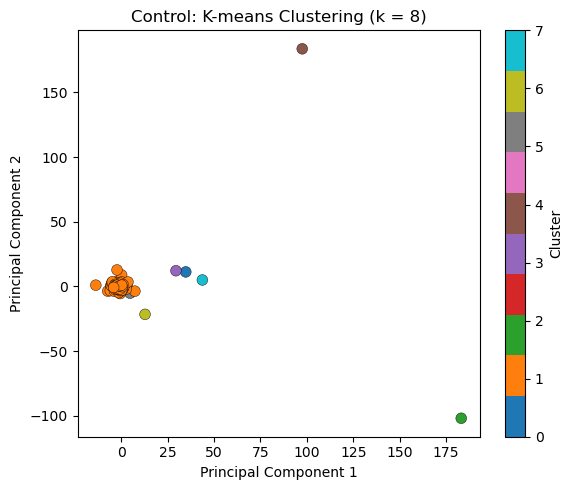

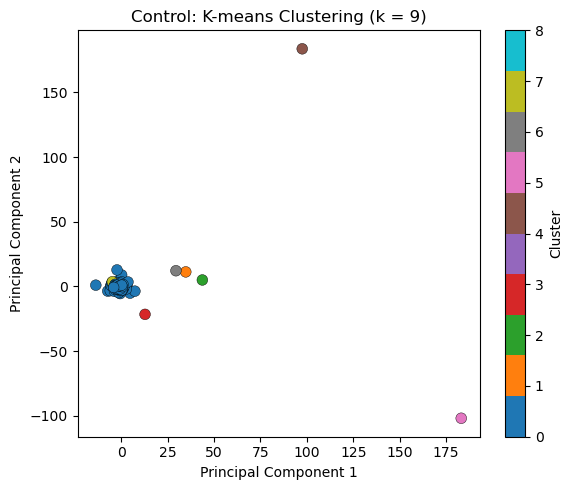

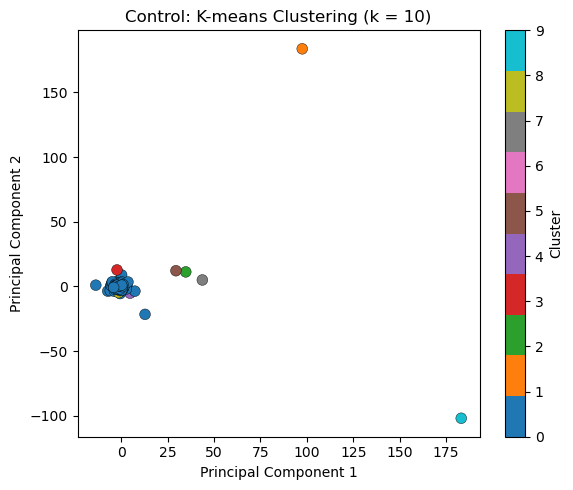

In [50]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
X = control_pca
k_values = range(2, 11)

for k in k_values:

    # Fit K-means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X)

    # Plot PCA
    plt.figure(figsize=(6, 5))

    plt.scatter(
        X[:, 0],          # PC1
        X[:, 1],          # PC2
        c=cluster_labels,
        cmap="tab10",
        s=60,
        edgecolor="black",
        linewidth=0.3
    )

    plt.title(f"Control: K-means Clustering (k = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

In [ ]:
# k = 3 looks better
# UMAP, visualization


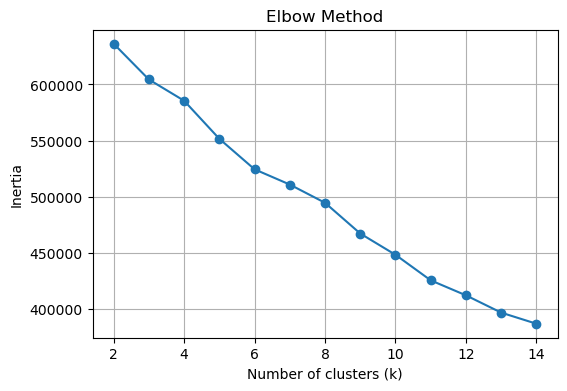

In [51]:
#Elbow method 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = coculture_pca

k_clusters = range(2, 15)
inertia = []

for k in k_clusters:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_clusters, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

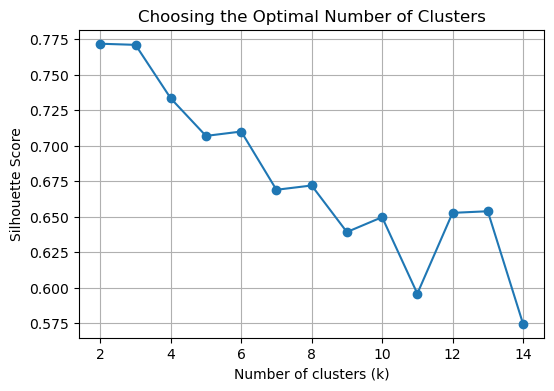

Best k according to silhouette score: 2


In [52]:
#Silhouette method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 15)
scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(control_pca)
    score = silhouette_score(control_pca, labels)
    scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Choosing the Optimal Number of Clusters")
plt.grid(True)
plt.show()
best_k = k_values[scores.index(max(scores))]
print(f"Best k according to silhouette score: {best_k}")

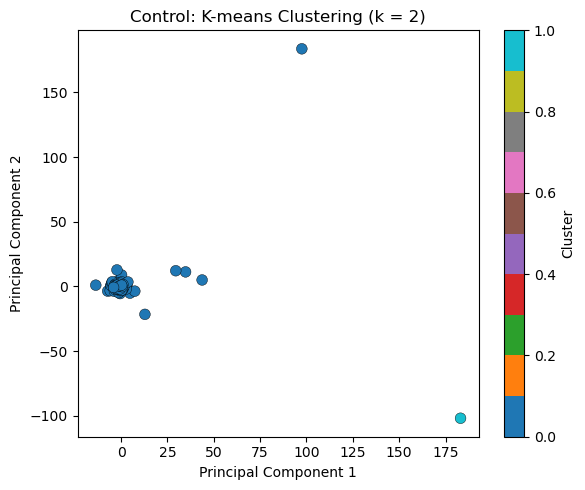

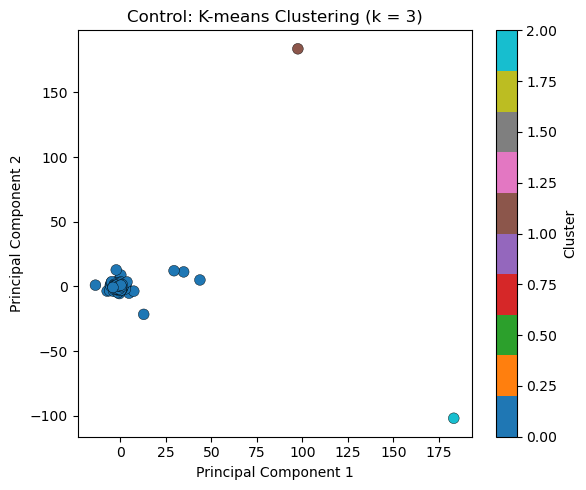

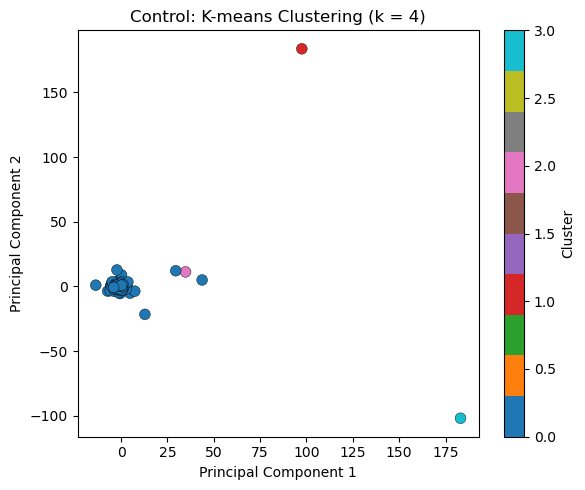

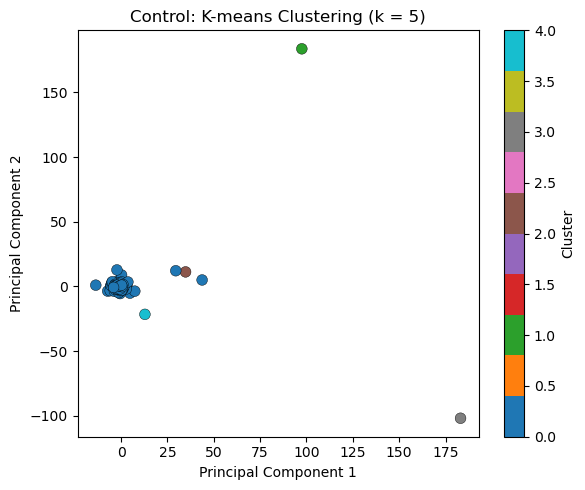

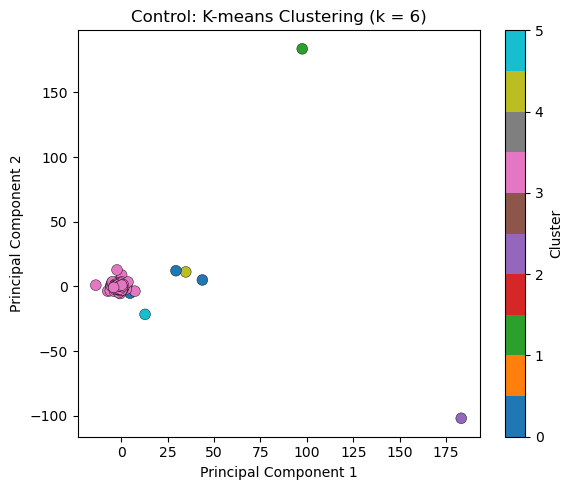

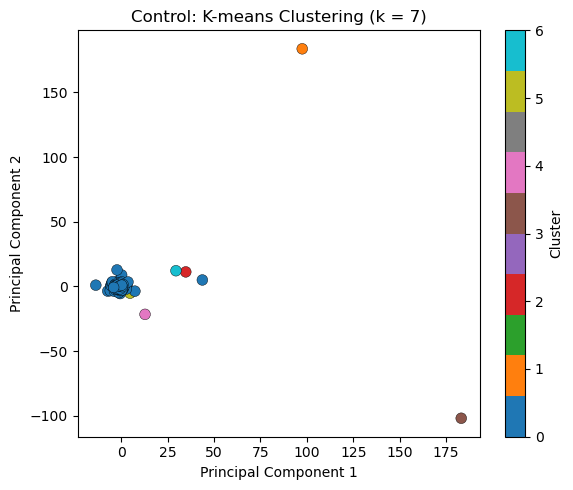

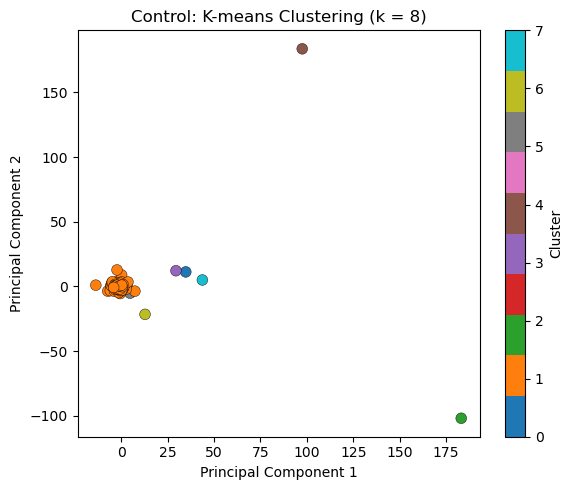

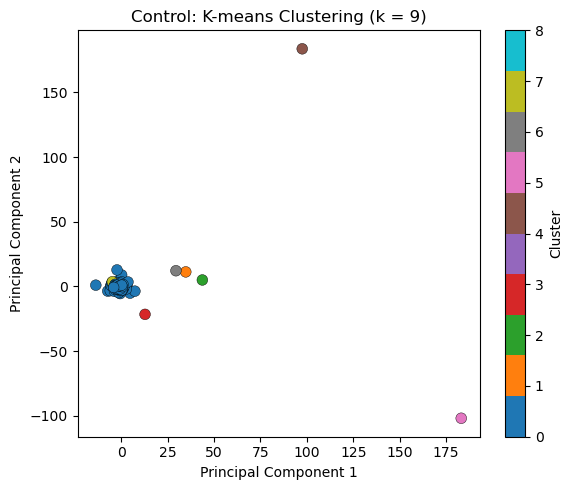

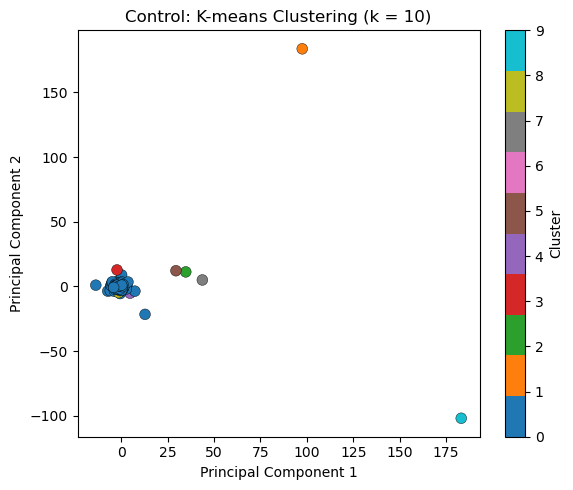

In [53]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
X = control_pca
k_values = range(2, 11)

for k in k_values:

    # Fit K-means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X)

    # Plot PCA
    plt.figure(figsize=(6, 5))

    plt.scatter(
        X[:, 0],          # PC1
        X[:, 1],          # PC2
        c=cluster_labels,
        cmap="tab10",
        s=60,
        edgecolor="black",
        linewidth=0.3
    )

    plt.title(f"Control: K-means Clustering (k = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

In [ ]:
#- Do the same perturbations cluster together in every condition?
#- Does IFNγ change the clustering?
#- Which perturbations behave differently in co-culture?